# 1. Загрузить при помощи kaggle api в Google collab

kaggle datasets download -d nexuswho/laboro-tomato -p /content --unzip



In [1]:
from itertools import accumulate

import cv2
import numpy as np

import cv2
from IPython.display import display
from PIL import Image

def show_image(img, max_size=312):
    h, w = img.shape[:2]
    scale = min(max_size / w, max_size / h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (new_w, new_h))
    if len(resized.shape) == 3:
        img_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        display(Image.fromarray(img_rgb))
    else:
        display(Image.fromarray(resized))


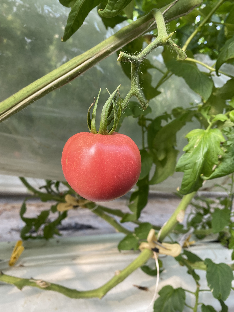

In [2]:
originalImage = cv2.imread('images/IMG_0990.jpg')
show_image(originalImage)

## Перевод в чб


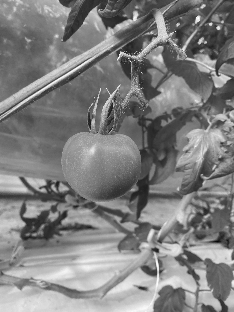

In [3]:
gray_image = cv2.cvtColor(originalImage, cv2.COLOR_BGR2GRAY)
show_image(gray_image)


## Фиксированное изменение размера

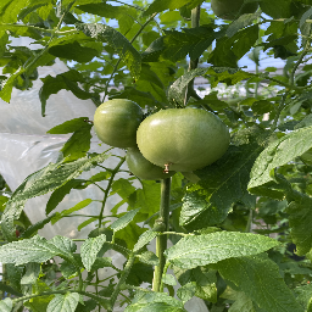

In [4]:
import cv2
img = cv2.imread('images/IMG_0984.jpg')
fixed_resized = cv2.resize(img, (256, 256))

show_image(fixed_resized)


## Пропорциональное изменение размера

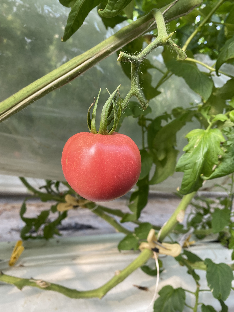

In [5]:
import cv2

h, w = originalImage.shape[:2]

max_size = 312

scale = min(max_size / w, max_size / h)
new_w, new_h = int(w * scale), int(h * scale)

resized = cv2.resize(originalImage, (new_w, new_h))
show_image(resized)

 ## Изменить порядок каналов

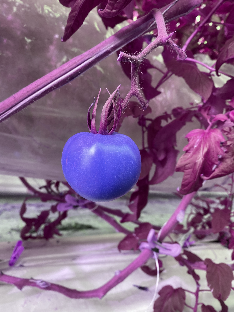

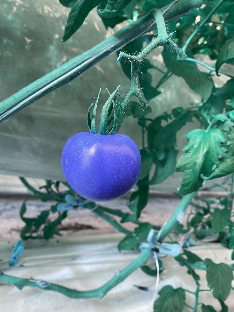

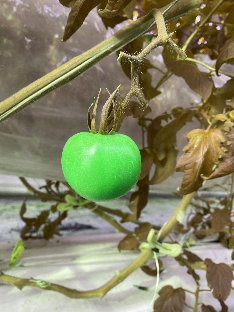

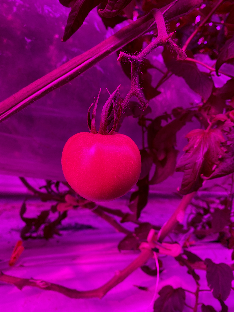

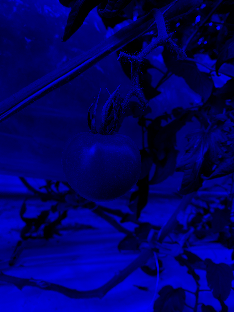

In [6]:
# изначально originalImage в [B, G, R]
# 2 - R, 0 - B, 1 - G

# (R, B, G)
img_rbg = originalImage.copy()
img_rbg = img_rbg[:, :, [2, 0, 1]].copy()

#  (R, G, B)
img_rgb = originalImage.copy()
img_rgb = img_rgb[:, :, [2, 1, 0]].copy()

# (B, R, G)
img_brg = originalImage.copy()
img_brg = img_brg[:, :, [0, 2, 1]].copy()

# (B, R, B)
img_brb = originalImage.copy()
img_brb[:, :, 1] = 0

# (B, B, B)
img_bbb = originalImage.copy()
img_bbb[:, :, 1] = 0
img_bbb[:, :, 2] = 0

show_image(img_rbg)
show_image(img_rgb)
show_image(img_brg)
show_image(img_brb)
show_image(img_bbb)

## Поворот

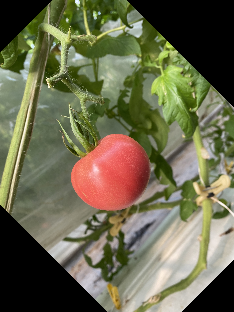

In [7]:
(h, w) = originalImage.shape[:2]
center = (w // 2, h // 2)

angle = 45 # против часовой
scale = 1.0

# матрица поворота
M = cv2.getRotationMatrix2D(center, angle, scale) # Аффинное преобразование

rotated = cv2.warpAffine(originalImage, M, (w, h))

show_image(rotated)

## Переместить центр изображения

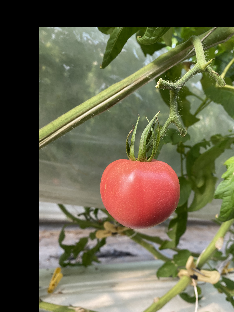

In [8]:


h, w = originalImage.shape[:2]

tx, ty = 500, 350  # вправо 100, вниз 50

# матрица трансляции
M = np.float32([[1, 0, tx],
                [0, 1, ty]])

shifted = cv2.warpAffine(originalImage, M, (w, h))

show_image(shifted)


## Рамка

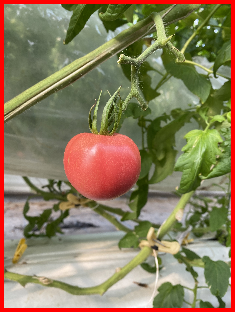

In [9]:
bordered = cv2.copyMakeBorder(
    originalImage,
    top=50, bottom=50, left=50, right=50,
    borderType=cv2.BORDER_CONSTANT,
    value=(0, 0, 255)
)

show_image(bordered)


## Отражения

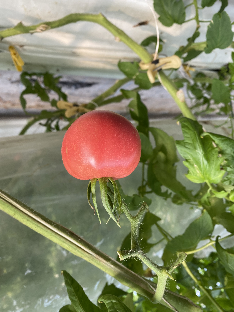

In [10]:
flipped = cv2.flip(originalImage, 0) # -1 0 1
show_image(flipped)

## Обрезание

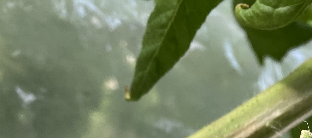

In [11]:
x1 = 250
x2 = 1600

y1 = 100
y2 = 700
crop = originalImage[y1:y2, x1:x2]
show_image(crop)

# 3. Фильтр соболя

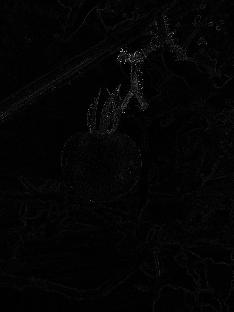

In [12]:
gray_image = cv2.cvtColor(originalImage, cv2.COLOR_BGR2GRAY)

kx  = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]], dtype=np.float32)
ky  = np.array([[-1, -2, -1],
               [0, 0, 0],
               [1, 2, 1]], dtype=np.float32)

test_img = np.array([ [10, 20, 30, 40, 50, 60],
                      [20, 30, 40, 50, 60, 70],
                      [30, 40, 50, 60, 70, 80],
                      [40, 50, 60, 70, 80, 90],
                      [50, 60, 70, 80, 90,100],
                      [60, 70, 80, 90,100,110] ], dtype=np.float32)


# свёртка
Gx = cv2.filter2D(gray_image, ddepth=cv2.CV_32F, kernel=kx, borderType=cv2.BORDER_CONSTANT)
Gy = cv2.filter2D(gray_image, ddepth=cv2.CV_32F, kernel=ky, borderType=cv2.BORDER_CONSTANT)



G = (Gx ** 2  +Gy ** 2) ** 0.5

G_my_Sobol_norm = (G / G.max()) * 255
G_my_Sobol_uint8 = G_my_Sobol_norm.astype(np.uint8)

show_image(G_my_Sobol_uint8)


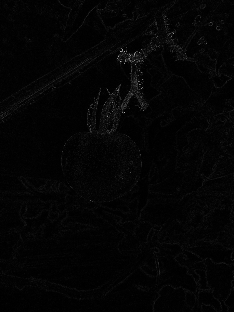

In [13]:
import cv2
import numpy as np


Gx_sobel = cv2.Sobel(gray_image, ddepth=cv2.CV_32F, dx=1, dy=0, ksize=3)
Gy_sobel = cv2.Sobel(gray_image, ddepth=cv2.CV_32F, dx=0, dy=1, ksize=3)

G_sobel = np.sqrt(Gx_sobel**2 + Gy_sobel**2)

G_sobel_norm = 255 * (G_sobel / G_sobel.max())
G_sobel_uint8 = G_sobel_norm.astype(np.uint8)

show_image(G_sobel_uint8)


# 1. Реализовать алгоритм Хаффа для поиска линий + 1

In [14]:
from IPython.display import HTML
HTML('''
<style>
img[src^="attachment:"], img[src*="attachment:"] {
  display: block;
  margin-left: auto;
  margin-right: auto;
  max-width: 400px !important;
  height: auto !important;
  margin-top: 20px;
  margin-bottom: 20px;
}
</style>
''')


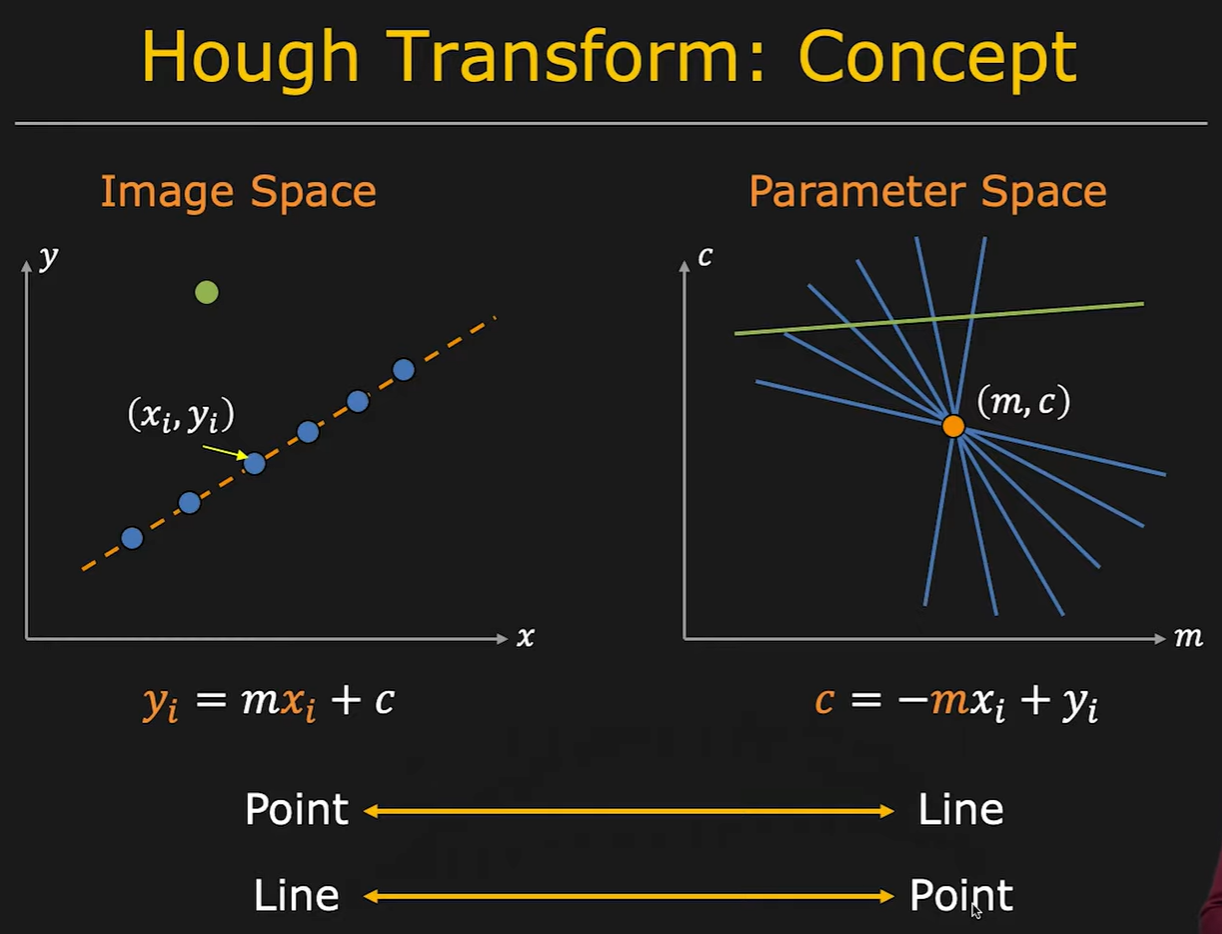

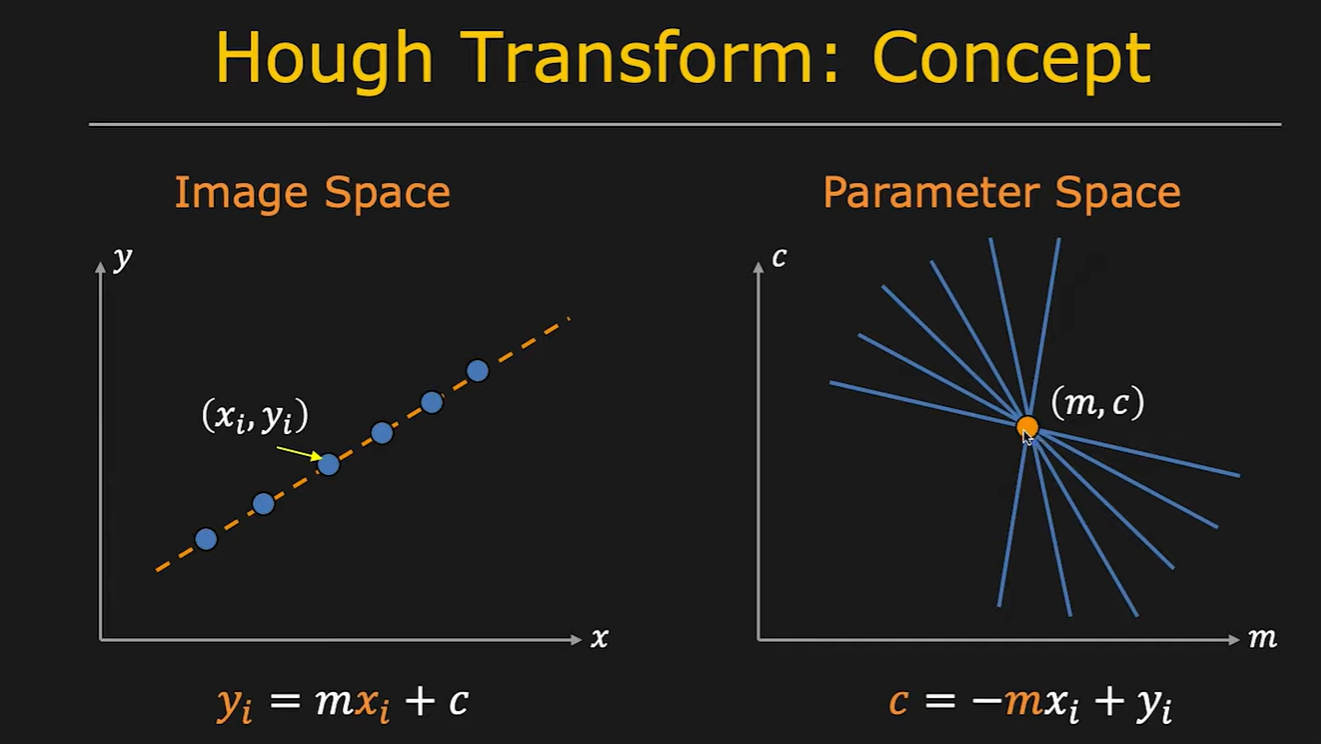
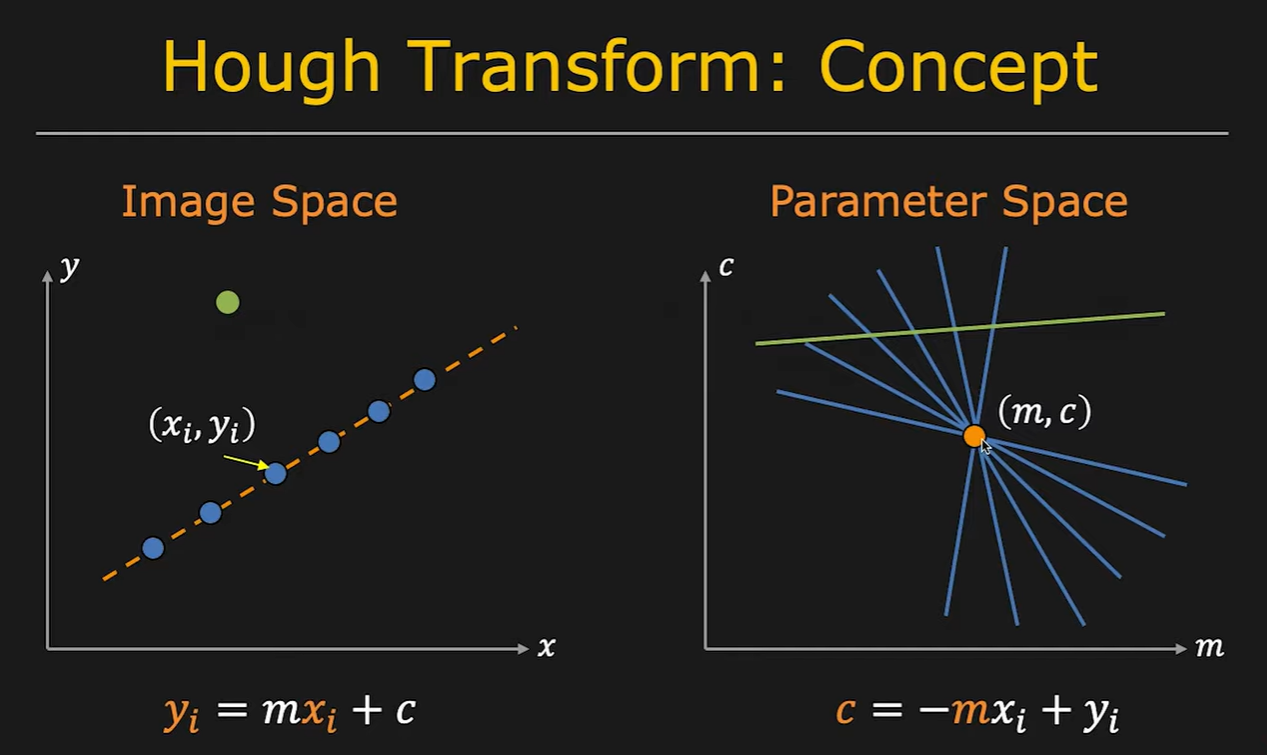
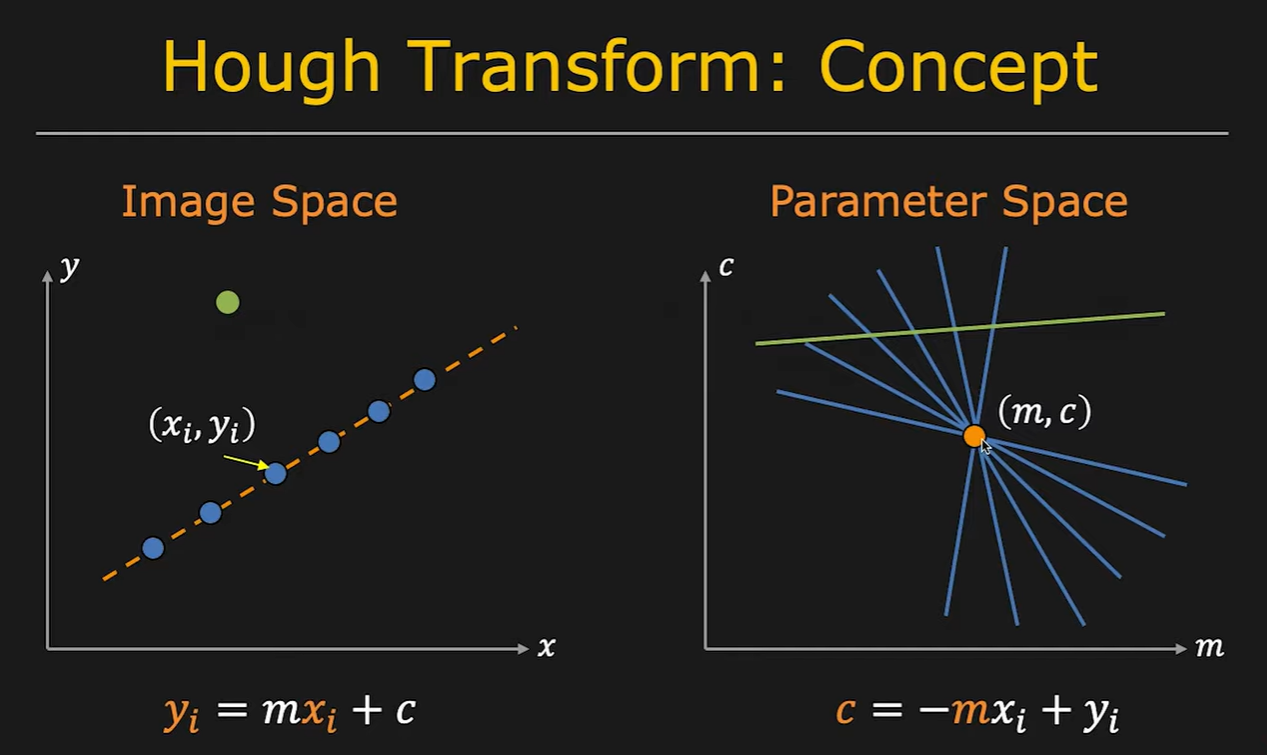
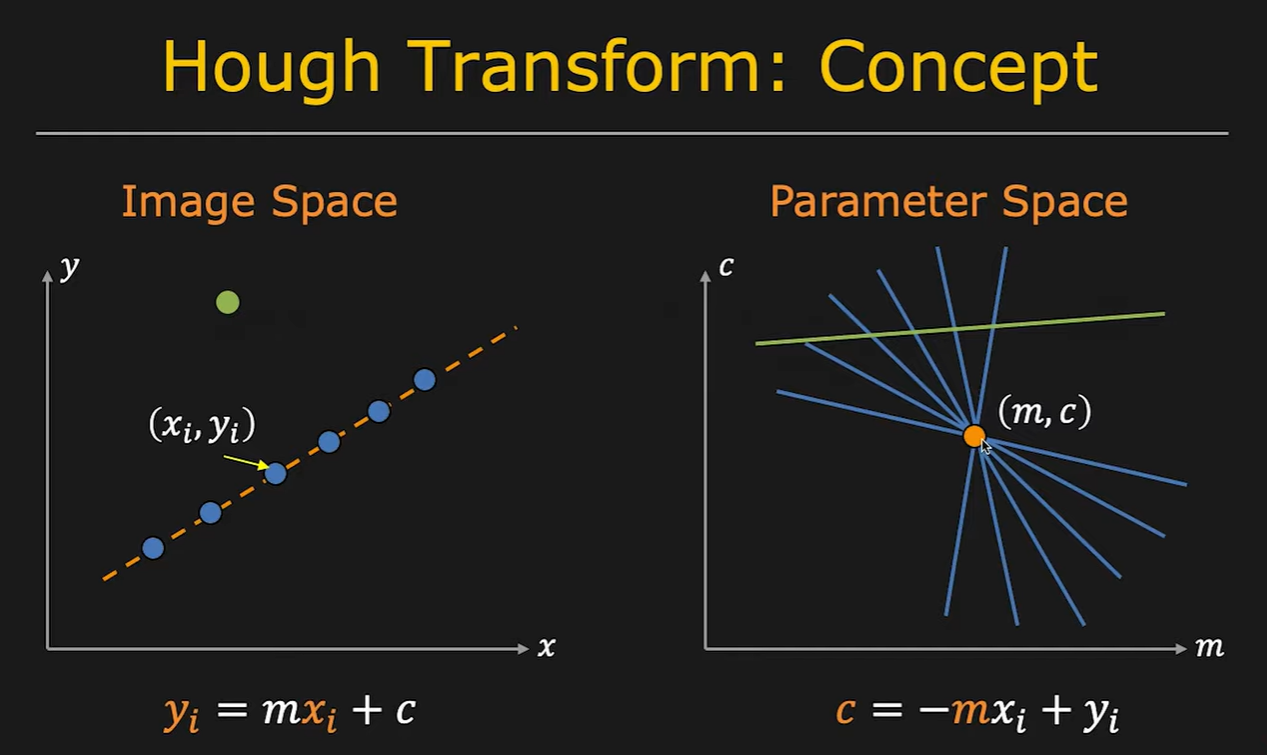

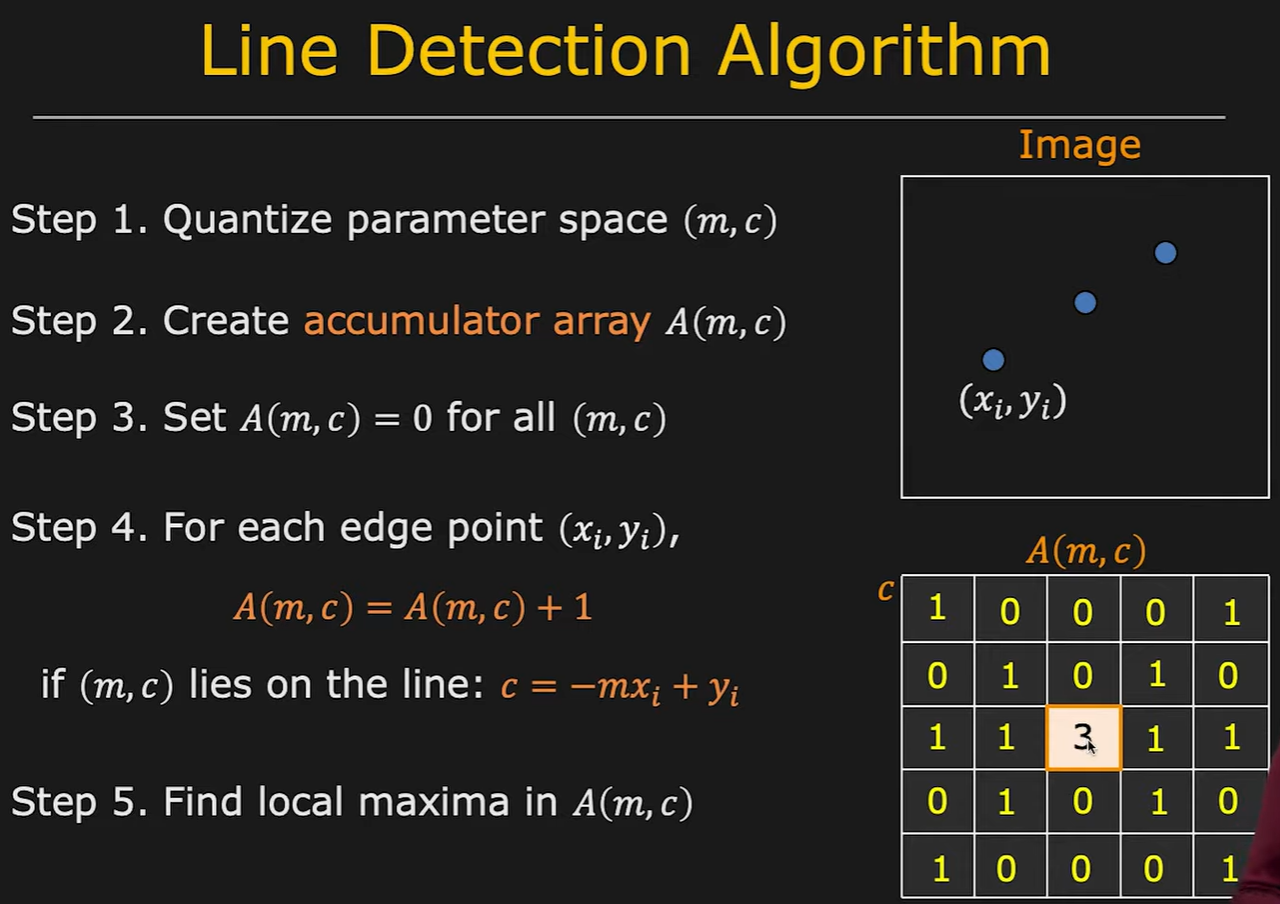

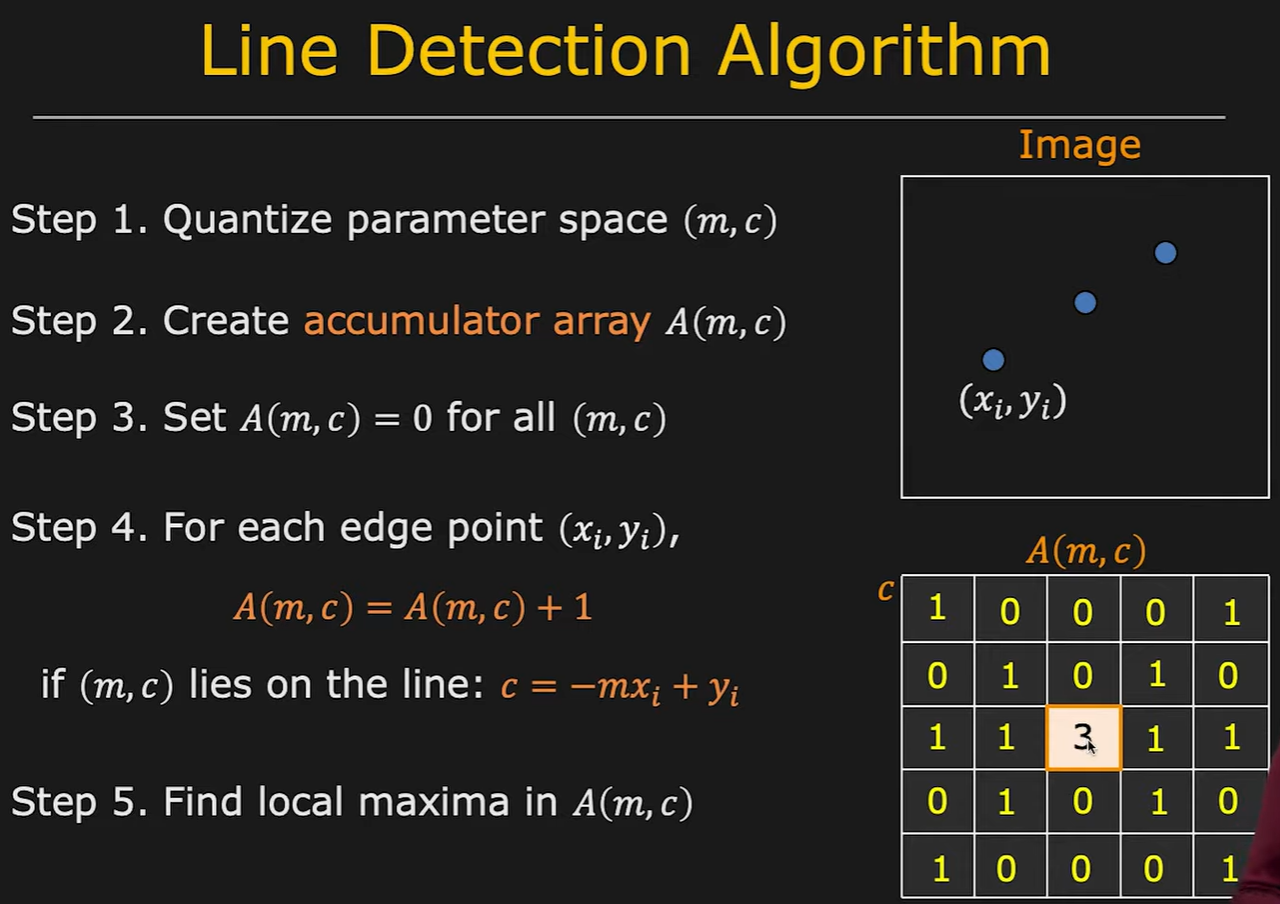
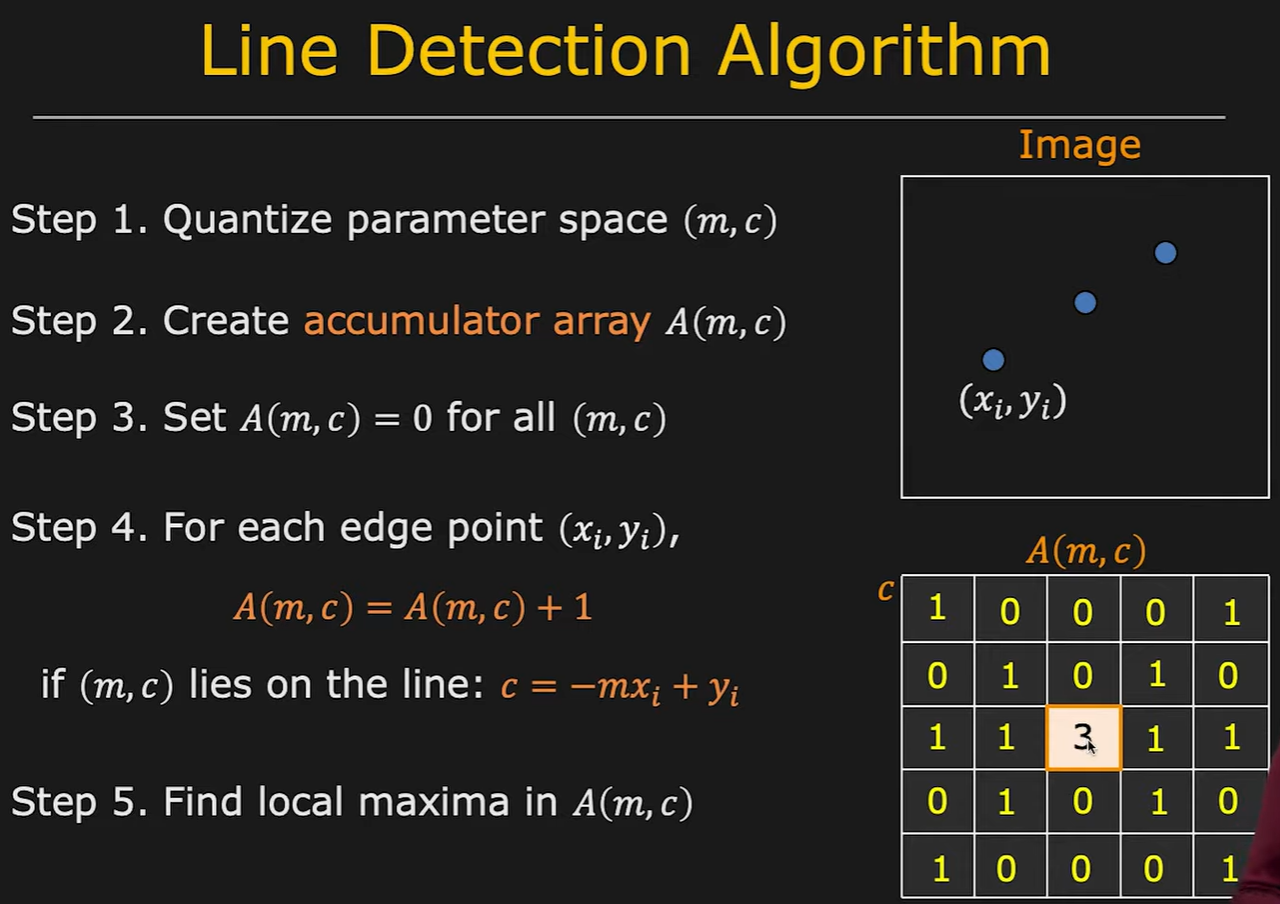

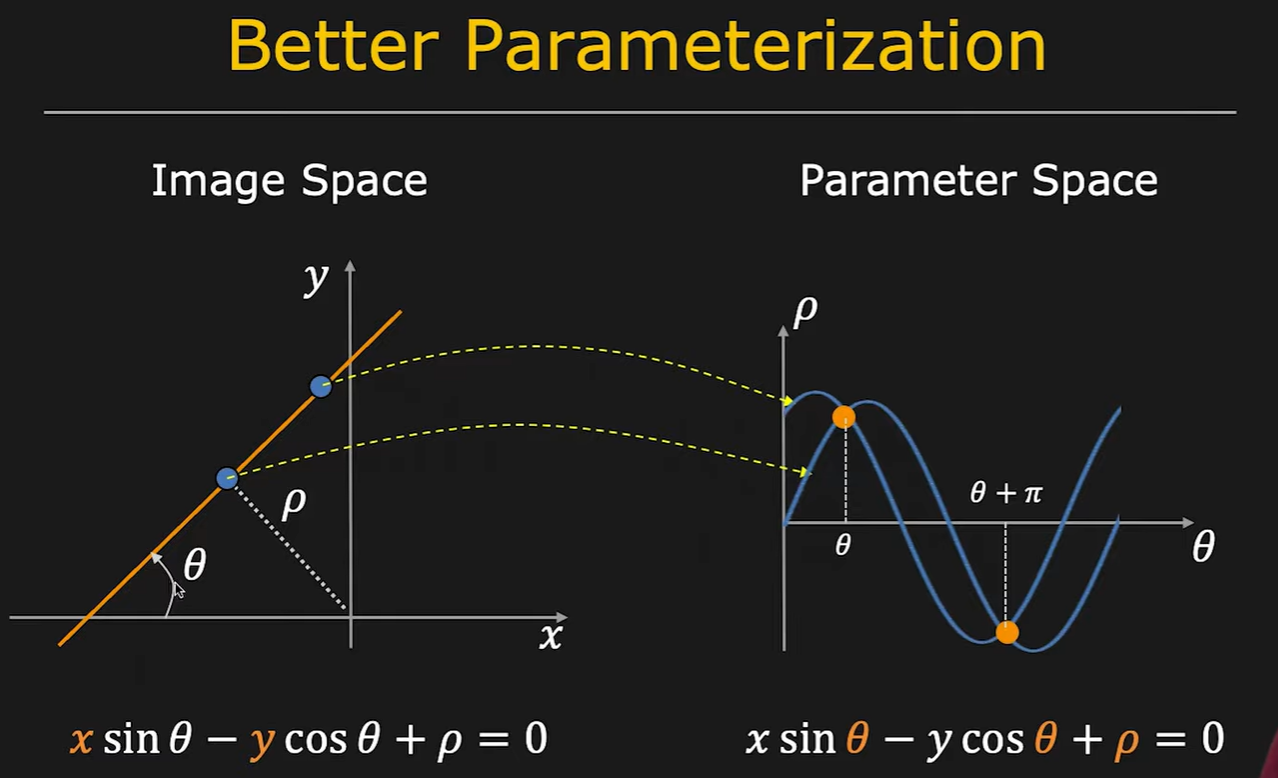


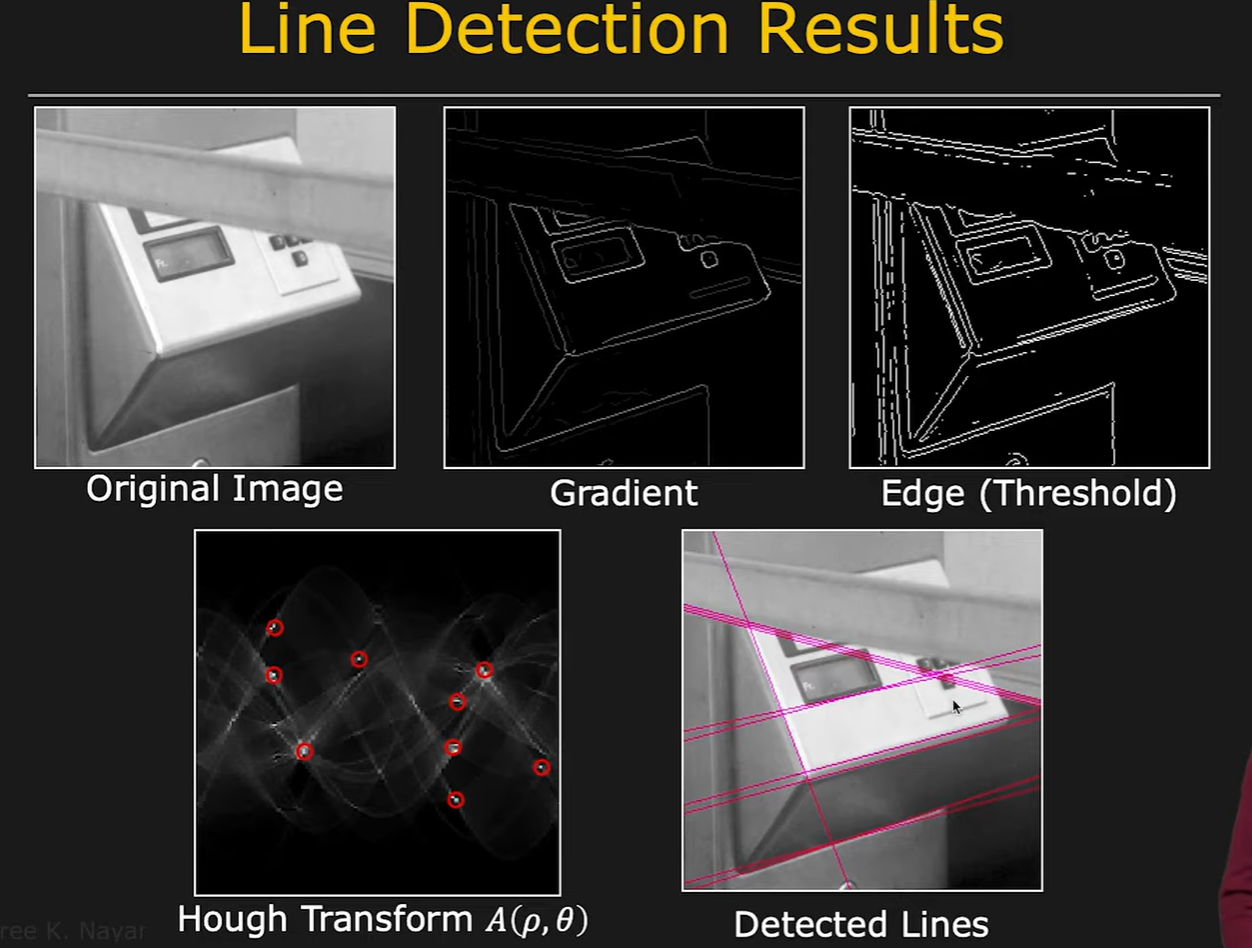

 $$ r = x cos{\Theta}  + y \sin{\Theta}$$

Алгоритм:

0. Фильтром Соболя находим "границы" + фильтруем по значению после фильтра Соболя.
1. Создаем матрицу аккумулятора ($\sqrt{W^2+H^2}$, 180)
2. Для каждой оставшейся точки, перебираем все $\Theta$ и вычисляем соответствующие $r$
3. Выбираем $n$ максимумов из аккумулятора (точки в этой матрице и есть наши прямые)
4. Оставляем (или выделяем) точки исходного изображения которые удовлетворяют этим $r,\Theta$

## 0. Фильтром Соболя находим "границы" + фильтруем по значению после фильтра Соболя.

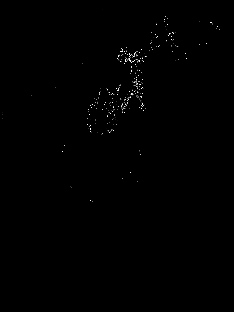

In [15]:

from matplotlib import pyplot as plt

T  = 50 # limit

edges = (G_my_Sobol_uint8 > T).astype(np.uint8)
show_image(edges * 255)
# plt.imshow(edges, cmap='gray', vmin=0, vmax=1)



## 1. Создаем матрицу аккумулятора ($\sqrt{W^2+H^2}$, 180)


In [16]:
H, W = edges.shape
diag = int((W**2 + H**2)**0.5)

accumulator = np.array( [[ 0  for _ in range(2 * diag + 1)] for _ in range(0, 180)] )
print(accumulator.shape)

(180, 10081)


## 2. Для каждой оставшейся точки, перебираем все $\Theta$ и вычисляем соответствующие $r$

In [64]:
thetas_rad = np.deg2rad(np.arange(0, 180))
cos_t = np.cos(thetas_rad)
sin_t = np.sin(thetas_rad)

votes_points = [ [ [] for _ in range(2*diag + 1) ] for _ in range(180) ]


for x in range(W-1):
    for y in range(H-1):
        if edges[y, x] == 1:
            for i in range(len(thetas_rad)):

                r = int(x * cos_t[i] + y * sin_t[i])
                r_idx = round(r + diag)
                accumulator[i, r_idx] += 1
                votes_points[i][r_idx].append((x, y))


## 3. Выбираем $n$ максимумов из аккумулятора (точки в этой матрице и есть наши прямые)


In [18]:
import numpy as np

def top_n_peaks(accumulator, N=10):
    flat = accumulator.ravel()
    top_idxs = np.argsort(flat)[-N:][::-1]
    peaks = [np.unravel_index(idx, accumulator.shape) + (flat[idx],) for idx in top_idxs]
    # peaks: list of (rho_idx, theta_idx, votes)  OR (theta_idx, rho_idx, votes) в зависимости от shape
    return peaks


In [56]:
peaks = top_n_peaks(accumulator, N=50)
# пример вывода одного пика:


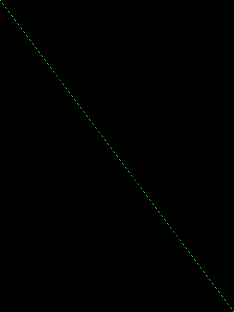

In [66]:
x_1  = W // 2

image = np.zeros((H, W, 3), np.uint8)
# image = originalImage
color = (0, 255, 0)
thickness = 2

for theta_idx, rho, votes in peaks:
    if theta_idx == 0:
        x_2 = x_1
        y_1 = x_1
        y_2 = y_1 + 100
    else:
        x_2 = x_1 + 100
        y_1 = round(- cos_t[theta_idx] / sin_t[theta_idx] * x_1 + (rho - diag) / sin_t[theta_idx])
        y_2 = round(- cos_t[theta_idx] / sin_t[theta_idx] * x_2 + (rho - diag) / sin_t[theta_idx])

    start_point = (x_1, y_1)
    end_point = (x_2, y_2)

    cv2.line(image, start_point, end_point, color, thickness)
show_image(image)
# cv2.imshow("Линия на изображении", image)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
